# 01 - Esplorazione Dati FarmaVita

I dati nel database PostgreSQL sono **normalizzati**: dovete fare JOIN per ricostruire il dataset di lavoro.

**Schema `raw`** (10 tabelle normalizzate):
- `daily_sales` — vendite giornaliere
- `stores`, `store_types`, `assortment_levels` — anagrafica negozi
- `competitions` — competitor
- `promo_daily`, `promo_continuous` — promozioni
- `state_holidays`, `school_holidays` — festività per stato
- `prediction_requests` — test set

**Schema `augmentation`** (5 tabelle con dati sporchi):
- `store_states` — chiave di join Store → State
- `weather`, `google_trends`, `macroeconomic`, `local_events`

> **Il DB e' sola lettura.** Consultare `docs/DATABASE_SCHEMA.md` per lo schema completo.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Caricare variabili d'ambiente dal file .env (se presente)
# pip install python-dotenv
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    print("python-dotenv non installato, configurare le variabili d'ambiente manualmente")

# Configurazione database sorgente (SOLA LETTURA)
DB_HOST = os.environ.get('DB_HOST', 'hackathon-farmavita-db.cjcn7vyqigdy.eu-west-1.rds.amazonaws.com')
DB_PORT = os.environ.get('DB_PORT', '5432')
DB_NAME = os.environ.get('DB_NAME', 'farmavita')
DB_USER = os.environ.get('DB_USER', 'hackathon_reader')
DB_PASSWORD = os.environ.get('DB_PASSWORD', 'ReadOnly_FarmaVita2026')

from sqlalchemy import create_engine
engine = create_engine(f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
print(f'Connesso a {DB_HOST} come {DB_USER} (sola lettura)')

Connesso a hackathon-farmavita-db.cjcn7vyqigdy.eu-west-1.rds.amazonaws.com come hackathon_reader (sola lettura)


## Esplorazione

Esplorare le tabelle, capire le relazioni e iniziare a costruire i JOIN.

In [4]:
# Tabelle disponibili nel database
tables_info = pd.read_sql("""
    SELECT schemaname, tablename
    FROM pg_tables
    WHERE schemaname IN ('raw', 'augmentation')
    ORDER BY schemaname, tablename
""", engine)
print("Tabelle disponibili:")
print(tables_info.to_string(index=False))

Tabelle disponibili:
  schemaname           tablename
augmentation       google_trends
augmentation        local_events
augmentation       macroeconomic
augmentation        store_states
augmentation             weather
         raw   assortment_levels
         raw        competitions
         raw         daily_sales
         raw prediction_requests
         raw    promo_continuous
         raw         promo_daily
         raw     school_holidays
         raw      state_holidays
         raw         store_types
         raw              stores


In [5]:
# Caricamento del dataset processato
df = pd.read_parquet('../intermediate_processed.parquet')
print(f'Shape: {df.shape[0]:,} righe x {df.shape[1]} colonne')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('\n--- Tipi di dato ---')
print(df.dtypes)
print('\n--- Prime 5 righe ---')
df.head()

Shape: 1,017,209 righe x 25 colonne
Memoria: 587.1 MB

--- Tipi di dato ---
store_id                              int64
date                         datetime64[ns]
sales                               float64
customers                           float64
is_open                               int64
is_train                              int64
id                                  float64
type_code                            object
description_type                     object
level_code                           object
description_assortment               object
state                                object
distance_meters                     float64
open_since_month                    float64
open_since_year                     float64
temperature_avg                     float64
temperature_min                     float64
temperature_max                     float64
precipitation_mm                    float64
weather_event                        object
gdp_index                           float64


,store_id,date,sales,customers,is_open,is_train,id,type_code,description_type,level_code,...,temperature_avg,temperature_min,temperature_max,precipitation_mm,weather_event,gdp_index,unemployment_rate,consumer_confidence_index,trend_index,has_local_event
0,1,2015-06-13,4256.0,502.0,1,1,NaN,c,"Compact - smaller format, suburban",a,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
1,2,2015-06-13,2574.0,319.0,1,1,NaN,a,"Standard - high footfall, urban locations",a,...,23.1,20.4,24.5,0.0,clear,112.87,9.07,NaN,66.0,0.0
2,3,2015-06-13,4687.0,492.0,1,1,NaN,a,"Standard - high footfall, urban locations",a,...,19.8,15.4,23.1,0.0,clear,NaN,NaN,NaN,NaN,0.0
3,4,2015-06-13,9779.0,1370.0,1,1,NaN,c,"Compact - smaller format, suburban",c,...,23.3,19.7,26.8,0.0,clear,NaN,NaN,NaN,NaN,0.0
4,5,2015-06-13,2156.0,234.0,1,1,NaN,a,"Standard - high footfall, urban locations",a,...,19.9,17.2,22.2,2.6,rain,NaN,NaN,NaN,55.0,0.0


In [6]:
# ========== DATA QUALITY CHECK ==========

# 1. Missing values per colonna
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing': missing, 'pct': missing_pct, 'dtype': df.dtypes})
missing_report = missing_report[missing_report['missing'] > 0].sort_values('pct', ascending=False)

if len(missing_report) > 0:
    print(f'=== COLONNE CON MISSING VALUES ({len(missing_report)}/{df.shape[1]}) ===')
    print(missing_report.to_string())
else:
    print('Nessun missing value trovato!')

# 2. Righe duplicate
n_dup = df.duplicated().sum()
print(f'\n=== RIGHE DUPLICATE: {n_dup:,} ===')

# 3. Controllo store_id + date duplicati (chiave naturale)
if {'store_id', 'date'}.issubset(df.columns):
    dup_keys = df.duplicated(subset=['store_id', 'date']).sum()
    print(f'Duplicati su (store_id, date): {dup_keys:,}')

# 4. Statistiche descrittive
print('\n=== STATISTICHE DESCRITTIVE (colonne numeriche) ===')
print(df.describe().round(2).to_string())

# 5. Controllo sales=0 su negozi aperti
if 'sales' in df.columns and 'is_open' in df.columns:
    zero_sales_open = ((df['is_open'] == 1) & (df['sales'] == 0)).sum()
    print(f'\n=== ANOMALIE ===')
    print(f'Negozi aperti con sales=0: {zero_sales_open:,}')

# 6. Valori negativi
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f'  Valori negativi in {col}: {n_neg:,}')

# 7. Range date
if 'date' in df.columns:
    dates = pd.to_datetime(df['date'], errors='coerce')
    print(f'\n=== RANGE DATE ===')
    print(f'Da {dates.min()} a {dates.max()}')
    print(f'Date non parsabili: {dates.isna().sum():,}')

# 8. Cardinalita colonne
print('\n=== CARDINALITA COLONNE ===')
for col in df.columns:
    n_unique = df[col].nunique()
    print(f'  {col}: {n_unique:,} valori unici')


=== COLONNE CON MISSING VALUES (16/25) ===
                           missing    pct    dtype
id                          963689  94.74  float64
unemployment_rate           761639  74.88  float64
gdp_index                   753729  74.10  float64
consumer_confidence_index   753565  74.08  float64
trend_index                 574335  56.46  float64
precipitation_mm            243085  23.90  float64
temperature_max             243038  23.89  float64
weather_event               242453  23.84   object
temperature_min             242172  23.81  float64
temperature_avg             242130  23.80  float64
has_local_event             234642  23.07  float64
sales                        53520   5.26  float64
customers                    53520   5.26  float64
open_since_month              2642   0.26  float64
distance_meters               2642   0.26  float64
open_since_year               2642   0.26  float64

=== RIGHE DUPLICATE: 0 ===
Duplicati su (store_id, date): 0

=== STATISTICHE DESCRITTIVE 

In [7]:
# ========== INVESTIGAZIONE VALORI ANOMALI ==========

# 1. Unemployment rate negativo — NON ha senso
neg_unemp = df[df['unemployment_rate'] < 0]
print(f'=== unemployment_rate < 0: {len(neg_unemp):,} righe ===')
print(df['unemployment_rate'].describe())
print(f'\nValori negativi unici: {sorted(df[df["unemployment_rate"] < 0]["unemployment_rate"].unique())[:10]}')

# Strategia: probabilmente un segno meno inserito per errore → valore assoluto
df['unemployment_rate'] = df['unemployment_rate'].abs()
print(f'\nDopo fix (abs): min={df["unemployment_rate"].min()}, max={df["unemployment_rate"].max()}')

# 2. Sales=0 con negozio aperto — rimuovere dal training (distorcono il modello)
if 'is_train' in df.columns:
    before = len(df)
    df = df[~((df['is_open'] == 1) & (df['sales'] == 0) & (df['is_train'] == True))]
    print(f'\n=== Rimossi {before - len(df)} record con sales=0 e negozio aperto (solo train) ===')

# 3. Verifica post-fix
print('\n=== CHECK POST-FIX ===')
for col in ['unemployment_rate', 'consumer_confidence_index']:
    n_neg = (df[col] < 0).sum()
    print(f'  {col} negativi: {n_neg:,}')
    print(f'    range: [{df[col].min():.2f}, {df[col].max():.2f}]')

print(f'\nShape finale: {df.shape[0]:,} righe x {df.shape[1]} colonne')


=== unemployment_rate < 0: 6,192 righe ===
count    255570.000000
mean          6.841802
std           3.110329
min          -4.890000
25%           4.740000
50%           6.870000
75%           9.960000
max          11.220000
Name: unemployment_rate, dtype: float64

Valori negativi unici: [np.float64(-4.89)]

Dopo fix (abs): min=3.2, max=11.22

=== Rimossi 54 record con sales=0 e negozio aperto (solo train) ===

=== CHECK POST-FIX ===
  unemployment_rate negativi: 0
    range: [3.20, 11.22]
  consumer_confidence_index negativi: 4,047
    range: [-101.61, 114.53]

Shape finale: 1,017,155 righe x 25 colonne


In [8]:
# ========== IMPUTATION NaN (STRATEGIE PER FEATURE) ==========

# Prima: vediamo quanti NaN ci sono
print("=== NaN PRIMA dell'imputation ===")
nan_before = df.isnull().sum()
print(nan_before[nan_before > 0].to_string())

# --- 1. Temperature: mediana per (state, month) ---
# Stesso stato + stesso mese → clima simile
df['_month'] = pd.to_datetime(df['date']).dt.month
for col in ['temperature_avg', 'temperature_min', 'temperature_max', 'precipitation_mm']:
    df[col] = df.groupby(['state', '_month'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Fallback: mediana globale per mese (se state intero mancante)
    df[col] = df.groupby('_month')[col].transform(
        lambda x: x.fillna(x.median())
    )

# --- 2. Macro-economici: forward fill per mese/anno (sono dati nazionali) ---
# Ordinati per data, il valore del mese precedente è il miglior proxy
df = df.sort_values('date')
for col in ['gdp_index', 'consumer_confidence_index']:
    df[col] = df[col].fillna(method='ffill').fillna(method='bfill')

# --- 3. Unemployment rate: mediana per (state, anno) ---
# Varia per stato e anno
df['_year'] = pd.to_datetime(df['date']).dt.year
df['unemployment_rate'] = df.groupby(['state', '_year'])['unemployment_rate'].transform(
    lambda x: x.fillna(x.median())
)
df['unemployment_rate'] = df['unemployment_rate'].fillna(df['unemployment_rate'].median())

# --- 4. Trend index: mediana per (state, month) ---
df['trend_index'] = df.groupby(['state', '_month'])['trend_index'].transform(
    lambda x: x.fillna(x.median())
)
df['trend_index'] = df['trend_index'].fillna(df['trend_index'].median())

# --- 5. Competition: mediana globale (è a livello store, non varia nel tempo) ---
df['distance_meters'] = df['distance_meters'].fillna(df['distance_meters'].median())
df['open_since_month'] = df['open_since_month'].fillna(df['open_since_month'].median())
df['open_since_year'] = df['open_since_year'].fillna(df['open_since_year'].median())

# --- 6. has_local_event: 0 = nessun evento (default sicuro) ---
df['has_local_event'] = df['has_local_event'].fillna(0)

# --- 7. is_open: 1 = aperto (default) ---
df['is_open'] = df['is_open'].fillna(1)

# Pulizia colonne temporanee
df.drop(columns=['_month', '_year'], inplace=True, errors='ignore')

# Verifica finale
print("\n=== NaN DOPO l'imputation ===")
nan_after = df.isnull().sum()
remaining = nan_after[nan_after > 0]
if len(remaining) > 0:
    print(remaining.to_string())
else:
    print("Nessun NaN rimasto nelle feature!")

# Riepilogo
print(f"\nNaN totali rimossi: {nan_before.sum() - nan_after.sum():,}")


=== NaN PRIMA dell'imputation ===
sales                         53520
customers                     53520
id                           963635
distance_meters                2642
open_since_month               2642
open_since_year                2642
temperature_avg              242113
temperature_min              242153
temperature_max              243021
precipitation_mm             243068
weather_event                242435
gdp_index                    753692
unemployment_rate            761602
consumer_confidence_index    753528
trend_index                  574305
has_local_event              234625

=== NaN DOPO l'imputation ===
sales             53520
customers         53520
id               963635
weather_event    242435

NaN totali rimossi: 4,056,033


In [9]:
# ========== FEATURE ENGINEERING (LIGHT) ==========
from sklearn.preprocessing import LabelEncoder

# Converti date in datetime
df['date'] = pd.to_datetime(df['date'])

# Feature temporali base
df['day_of_week'] = df['date'].dt.dayofweek       # 0=lun, 6=dom
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_month'] = df['date'].dt.day
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Anzianità competitor (mesi dalla data)
df['competition_open_months'] = (
    (df['year'] - df['open_since_year']) * 12 +
    (df['month'] - df['open_since_month'])
).clip(lower=0)

# Encoding categoriche
label_encoders = {}
for col in ['type_code', 'level_code', 'state', 'weather_event']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Feature da usare (NO customers — non disponibile a prediction time, NO sales)
feature_cols = [
    'store_id', 'is_open', 'day_of_week', 'month', 'year', 'day_of_month',
    'week_of_year', 'is_weekend', 'distance_meters', 'competition_open_months',
    'temperature_avg', 'temperature_min', 'temperature_max', 'precipitation_mm',
    'gdp_index', 'unemployment_rate', 'consumer_confidence_index',
    'trend_index', 'has_local_event',
    'type_code_enc', 'level_code_enc', 'state_enc', 'weather_event_enc',
]

print(f'Feature totali: {len(feature_cols)}')
print(feature_cols)


Feature totali: 23
['store_id', 'is_open', 'day_of_week', 'month', 'year', 'day_of_month', 'week_of_year', 'is_weekend', 'distance_meters', 'competition_open_months', 'temperature_avg', 'temperature_min', 'temperature_max', 'precipitation_mm', 'gdp_index', 'unemployment_rate', 'consumer_confidence_index', 'trend_index', 'has_local_event', 'type_code_enc', 'level_code_enc', 'state_enc', 'weather_event_enc']


In [10]:
# ========== FEATURE ENGINEERING v2 ==========

# Assicurati che date sia datetime
df['date'] = pd.to_datetime(df['date'])

# --- Ciclicità (sin/cos) per le feature temporali top ---
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['woy_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['woy_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

# --- Media vendite per store (target encoding dal solo train) ---
train_only = df[df['is_train'] == True]
store_avg_sales = train_only.groupby('store_id')['sales'].mean().rename('store_avg_sales')
store_med_sales = train_only.groupby('store_id')['sales'].median().rename('store_med_sales')
df = df.merge(store_avg_sales, on='store_id', how='left')
df = df.merge(store_med_sales, on='store_id', how='left')

# --- Media vendite per store × day_of_week ---
store_dow_avg = train_only.groupby(['store_id', 'day_of_week'])['sales'].mean().rename('store_dow_avg')
df = df.merge(store_dow_avg, on=['store_id', 'day_of_week'], how='left')

# --- Media vendite per state × month ---
state_month_avg = train_only.groupby(['state', 'month'])['sales'].mean().rename('state_month_avg')
df = df.merge(state_month_avg, on=['state', 'month'], how='left')

# --- Interazioni tra feature top ---
df['distance_x_type'] = df['distance_meters'] * df['type_code_enc']
df['store_type_assort'] = df['type_code_enc'] * 10 + df['level_code_enc']

# --- Giorno dell'anno (stagionalità fine) ---
df['day_of_year'] = df['date'].dt.dayofyear

# Fill NaN nelle nuove feature
for col in ['store_avg_sales', 'store_med_sales', 'store_dow_avg', 'state_month_avg']:
    df[col] = df[col].fillna(df[col].median())

# Aggiorna lista feature
feature_cols_v2 = feature_cols + [
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'woy_sin', 'woy_cos',
    'store_avg_sales', 'store_med_sales', 'store_dow_avg', 'state_month_avg',
    'distance_x_type', 'store_type_assort', 'day_of_year',
]

feature_cols_v2 += ['promo', 'has_promo2', 'promo2_active']
print(f'Feature totali: {len(feature_cols_v2)}')


Feature totali: 39


In [11]:
# ========== AGGIUNTA FEATURE PROMO DAL DB ==========

# 1. Promo giornaliera (se la coppia store_id+date esiste → promo attiva)
promo_daily = pd.read_sql("SELECT store_id, date, 1 as promo FROM raw.promo_daily", engine)
promo_daily['date'] = pd.to_datetime(promo_daily['date'], format='mixed')
df['date'] = pd.to_datetime(df['date'], format='mixed')
df = df.merge(promo_daily, on=['store_id', 'date'], how='left')
df['promo'] = df['promo'].fillna(0).astype(int)

# 2. Promo2 continua (calcola se era attiva in quella data)
promo_cont = pd.read_sql("SELECT * FROM raw.promo_continuous", engine)

month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

def is_promo2_active(row, promo_cont_df):
    match = promo_cont_df[promo_cont_df['store_id'] == row['store_id']]
    if match.empty:
        return 0
    p = match.iloc[0]
    # Promo2 non ancora iniziata?
    start = pd.Timestamp(year=int(p['since_year']), month=1, day=1) + pd.Timedelta(weeks=int(p['since_week']))
    if row['date'] < start:
        return 0
    # Il mese corrente è tra quelli attivi?
    active = [month_map.get(m.strip(), 0) for m in str(p['active_months']).split(',')]
    return 1 if row['date'].month in active else 0

# Pre-calcolo per velocità (merge + logica vettoriale)
df = df.merge(promo_cont[['store_id', 'since_week', 'since_year', 'active_months']],
              on='store_id', how='left')
df['has_promo2'] = df['since_year'].notna().astype(int)

# Calcolo vettoriale se promo2 è attiva
df['promo2_start'] = pd.to_datetime(
    df['since_year'].fillna(2000).astype(int).astype(str) + '-01-01'
) + pd.to_timedelta(df['since_week'].fillna(0) * 7, unit='D')

df['promo2_active_months'] = df['active_months'].fillna('')
df['promo2_active'] = 0
for month_name, month_num in month_map.items():
    mask = (df['promo2_active_months'].str.contains(month_name, na=False) &
            (df['date'].dt.month == month_num) &
            (df['date'] >= df['promo2_start']))
    df.loc[mask, 'promo2_active'] = 1

# Pulizia colonne temporanee
df.drop(columns=['since_week', 'since_year', 'active_months',
                 'promo2_start', 'promo2_active_months'], inplace=True)

print(f"Promo attiva: {df['promo'].sum():,} giorni")
print(f"Promo2 attiva: {df['promo2_active'].sum():,} giorni")
print(f"Stores con Promo2: {df['has_promo2'].sum():,}")

Promo attiva: 388,059 giorni
Promo2 attiva: 151,161 giorni
Stores con Promo2: 509,139


In [12]:
# ========== VALIDATION SPLIT TEMPORALE ==========
train_data = df[df['is_train'] == True].copy()
train_data = train_data[train_data['is_open'] == 1]

# Ultimi 6 settimane come validation (simula la situazione reale)
cutoff_date = train_data['date'].max() - pd.Timedelta(weeks=6)
tr = train_data[train_data['date'] <= cutoff_date]
val = train_data[train_data['date'] > cutoff_date]

X_tr = tr[feature_cols_v2].fillna(0)
y_tr = tr['sales']
X_val = val[feature_cols_v2].fillna(0)
y_val = val['sales']

print(f'Train:      {len(tr):,} righe  (fino a {cutoff_date.date()})')
print(f'Validation: {len(val):,} righe  (da {val["date"].min().date()} a {val["date"].max().date()})')

Train:      760,983 righe  (fino a 2015-05-02)
Validation: 37,471 righe  (da 2015-05-03 a 2015-06-13)


In [29]:
# ========== XGBOOST + GRIDSEARCH ==========
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# --- RMSPE custom metric (metrica dell'hackathon) ---
def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

# Scikit-learn farà internamente: RMSPE * -1
scorer = make_scorer(rmspe, greater_is_better=False)


In [30]:
# ========== OPTUNA - TRAINING SU LOG(SALES) ==========
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Validation split temporale
train_data = df[df['is_train'] == True].copy()
train_data = train_data[train_data['is_open'] == 1]

cutoff_date = train_data['date'].max() - pd.Timedelta(weeks=6)
tr = train_data[train_data['date'] <= cutoff_date]
val = train_data[train_data['date'] > cutoff_date]

X_tr = tr[feature_cols_v2].fillna(0)
y_tr = np.log1p(tr['sales'])          # target in log
X_val = val[feature_cols_v2].fillna(0)
y_val_log = np.log1p(val['sales'])     # target in log per eval_set
y_val_orig = val['sales'].values       # originale per RMSPE

print(f'Train:      {len(tr):,} righe  (fino a {cutoff_date.date()})')
print(f'Validation: {len(val):,} righe  (da {val["date"].min().date()} a {val["date"].max().date()})')

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 6, 14),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'gamma': trial.suggest_float('gamma', 0, 5),
    }

    model = XGBRegressor(
        **params,
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val_log)], verbose=False)

    # Predici in log → riconverti → RMSPE sulla scala originale
    pred_orig = np.expm1(model.predict(X_val)).clip(min=0)
    return rmspe(y_val_orig, pred_orig)

study = optuna.create_study(direction='minimize', study_name='xgboost_log_sales')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\n=== RISULTATI ===')
print(f'Best RMSPE: {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')


Train:      760,983 righe  (fino a 2015-05-02)
Validation: 37,471 righe  (da 2015-05-03 a 2015-06-13)


Best trial: 74. Best value: 0.134972: 100%|███| 100/100 [1:02:46<00:00, 37.67s/it]


=== RISULTATI ===
Best RMSPE: 0.1350
Best params:
  max_depth: 13
  n_estimators: 800
  learning_rate: 0.022917781729045676
  subsample: 0.6141948864529791
  colsample_bytree: 0.5826796528609031
  min_child_weight: 17
  reg_alpha: 0.0023031836504777002
  reg_lambda: 0.0021033342332997685
  gamma: 0.013077314513867448


RMSPE Validation (log-trained): 0.1350
MAE:  658
Media sales reali: 7,257


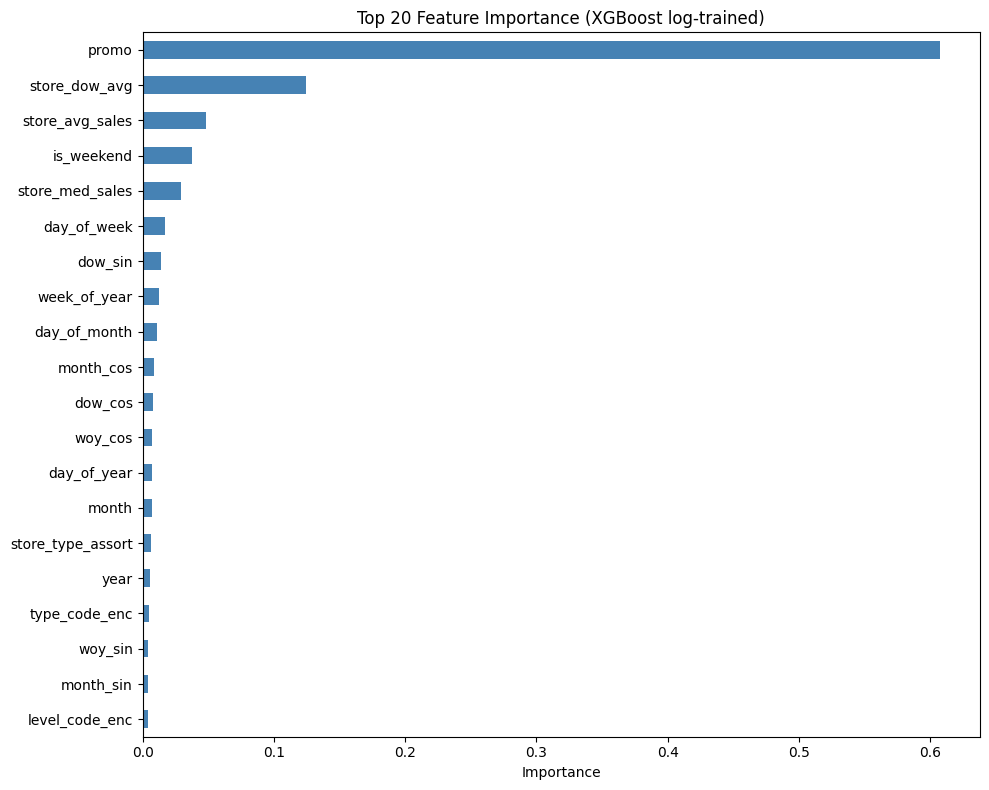

In [31]:
# ========== VALUTAZIONE SU VALIDATION SET ==========
best_v2 = XGBRegressor(
    **study.best_params,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
)
best_v2.fit(X_tr, y_tr, eval_set=[(X_val, y_val_log)], verbose=False)

# Predici in log → riconverti alla scala originale
val_pred = np.expm1(best_v2.predict(X_val)).clip(min=0)
val_rmspe = rmspe(y_val_orig, val_pred)

print(f'RMSPE Validation (log-trained): {val_rmspe:.4f}')
print(f'MAE:  {np.mean(np.abs(y_val_orig - val_pred)):,.0f}')
print(f'Media sales reali: {y_val_orig.mean():,.0f}')

# Feature Importance (top 20)
importances_v2 = pd.Series(best_v2.feature_importances_, index=feature_cols_v2)
top20 = importances_v2.sort_values(ascending=True).tail(20)

plt.figure(figsize=(10, 8))
top20.plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importance (XGBoost log-trained)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [34]:
# ========== PREDIZIONI FINALI (TEST SET) ==========
train_final = df[(df['is_train'] == True) & (df['is_open'] == 1)].copy()
test_final = df[df['is_train'] == False].copy()

X_train_full = train_final[feature_cols_v2].fillna(0)
y_train_full = np.log1p(train_final['sales'])  # log target
X_test_full = test_final[feature_cols_v2].fillna(0)

final_model = XGBRegressor(
    **study.best_params,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
)
final_model.fit(X_train_full, y_train_full,
    eval_set=[(X_train_full, y_train_full)], verbose=False)

# Predizioni: log → expm1 → scala originale
test_final['predicted_sales'] = 0
open_mask = test_final['is_open'] == 1
test_final.loc[open_mask, 'predicted_sales'] = np.expm1(
    final_model.predict(X_test_full[open_mask])).clip(min=0)

print(f'Predizioni finali: {len(test_final):,}')
print(f'  Media: {test_final["predicted_sales"].mean():,.0f}')
print(f'  Min:   {test_final["predicted_sales"].min():,.0f}')
print(f'  Max:   {test_final["predicted_sales"].max():,.0f}')

# Submission
submission = test_final[['id', 'predicted_sales']].copy()
submission.columns = ['id', 'sales']
submission.to_csv('../submission_v2.csv', index=False)
print("\nSalvata in '../submission_v2.csv'")

Predizioni finali: 53,520
  Media: 6,034
  Min:   0
  Max:   28,190

Salvata in '../submission_v2.csv'


In [33]:
# Salva il dataset completo con tutte le feature
df.to_parquet('../docs/df_final_features.parquet', index=False)
print(f"Salvato: {df.shape[0]:,} righe x {df.shape[1]} colonne")

Salvato: 1,017,155 righe x 52 colonne


In [13]:
# Salva solo il test set in parquet
test_set = df[df['is_train'] == False].copy()
test_set.to_parquet('../docs/test_set_features.parquet', index=False)
print(f"Test set salvato: {test_set.shape[0]:,} righe x {test_set.shape[1]} colonne")


Test set salvato: 53,520 righe x 52 colonne


In [36]:
# ========== SALVATAGGIO MODELLO E FEATURE IMPORTANCE ==========
import pickle

# 1. Feature Importance → TXT
importances = pd.Series(final_model.feature_importances_, index=feature_cols_v2)
importances = importances.sort_values(ascending=False)

with open('../src/models/feature_importance.txt', 'w') as f:
    f.write('Feature Importance (XGBoost - log-trained)\n')
    f.write('=' * 50 + '\n\n')
    for feat, imp in importances.items():
        f.write(f'{feat:40s} {imp:.6f}\n')
    f.write(f'\nTotale feature: {len(importances)}\n')
    f.write(f'RMSPE Validation: {val_rmspe:.4f}\n')
    f.write(f'Best params: {study.best_params}\n')

print("Feature importance salvata in 'models/feature_importance.txt'")

# 2. Modello → PKL (include pesi + parametri + tutto)
with open('../src/models/xgboost_model.pkl', 'wb') as f:
    pickle.dump({
        'model': final_model,
        'feature_cols': feature_cols_v2,
        'best_params': study.best_params,
        'val_rmspe': val_rmspe,
        'log_target': True,  # ricordati che predice in log!
    }, f)

print("Modello salvato in 'models/xgboost_model.pkl'")


Feature importance salvata in 'models/feature_importance.txt'
Modello salvato in 'models/xgboost_model.pkl'


## Prossimi passi

1. **Esplorare ogni tabella**: capire struttura, tipi, relazioni
2. **Ricostruire il dataset completo**: fare i JOIN necessari
3. **Pulire i dati augmentation**: risolvere i problemi di qualita'
4. **Feature engineering**: creare feature derivate
5. **Modello ML**: addestrare e valutare con RMSPE
6. **API e RAG**: costruire gli endpoint e il Sales Advisor